Experiment 1: Implement MLP and CNN for handwritten digit classification. Compare the results in terms of accuracy, F1 score. Plot train vs validation curve. Report the test accuracy and F1 score

Use MNIST dataset. Split into train, val and test sets in the ratio 60: 20:20. Before split sufffle the data.

Tune hyperparameters : learning rate, epoch, batch size.

In [1]:
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
import numpy as np

train_ds = datasets.MNIST(root="./data", train=True, download=True)
test_ds  = datasets.MNIST(root="./data", train=False, download=True)

X_data = np.concatenate([train_ds.data.numpy(), test_ds.data.numpy()], axis=0)
Y_data = np.concatenate([train_ds.targets.numpy(), test_ds.targets.numpy()], axis=0)

In [2]:
epochs = 100
learning_rate = 0.00001
batch_size = 10

In [3]:

# First split: 60% train, 40% temporary
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X_data,
    Y_data,
    test_size=0.4,
    random_state=42,
    shuffle=True
)

# Second split: divide the remaining 40% equally
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.5,
    random_state=45,
    shuffle=True
)

In [4]:
# Check sizes
print("Train:", X_train.shape, Y_train.shape)
print("Validation:", X_val.shape, Y_val.shape)
print("Test:", X_test.shape, Y_test.shape)

Train: (42000, 28, 28) (42000,)
Validation: (14000, 28, 28) (14000,)
Test: (14000, 28, 28) (14000,)


In [5]:
x_train_norm = X_train.astype("float32")/255
x_test_norm = X_test.astype("float32")/255
x_val_norm = X_val.astype("float32")/255

In [6]:
import matplotlib.pyplot as plt

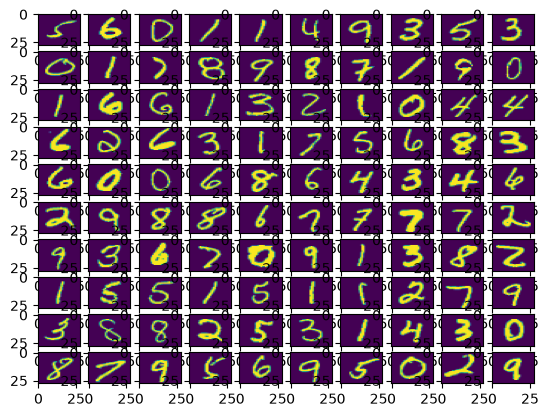

In [7]:
fig, ax = plt.subplots(10, 10)
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train_norm[k].reshape(28, 28), aspect='auto')
        k += 1
plt.show()

In [8]:
import torch
import torch.nn as nn

print(torch.__version__)
print(torch.cuda.is_available())

2.13.0+cu130
False


In [9]:
model = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

print(model)

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
)


In [10]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

model = model.to(device)

Device: cpu


In [11]:
# Convert NumPy arrays to PyTorch tensors

X_train_tensor = torch.tensor(x_train_norm, dtype=torch.float32)
X_val_tensor   = torch.tensor(x_val_norm, dtype=torch.float32)
X_test_tensor  = torch.tensor(x_test_norm, dtype=torch.float32)

Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)
Y_val_tensor   = torch.tensor(Y_val, dtype=torch.long)
Y_test_tensor  = torch.tensor(Y_test, dtype=torch.long)

In [12]:
X_train_tensor = X_train_tensor.reshape(-1, 784)
X_val_tensor   = X_val_tensor.reshape(-1, 784)
X_test_tensor  = X_test_tensor.reshape(-1, 784)

In [13]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, Y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, Y_test_tensor)

In [14]:
# batch_size = 10

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [15]:
criterion = nn.CrossEntropyLoss()

In [16]:
# learning_rate = 0.00001

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

In [17]:
# epochs = 100

train_losses_mlp = []
val_losses_mlp = []

train_accuracies_mlp = []
val_accuracies_mlp = []

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, Y_batch in train_loader:

        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        # Forward pass
        outputs = model(X_batch)

        # Calculate loss
        loss = criterion(outputs, Y_batch)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        # Predictions
        _, predicted = torch.max(outputs, 1)

        total += Y_batch.size(0)
        correct += (predicted == Y_batch).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, Y_batch in val_loader:

            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, Y_batch)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += Y_batch.size(0)
            correct += (predicted == Y_batch).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = correct / total

    # Store results
    train_losses_mlp.append(train_loss)
    val_losses_mlp.append(val_loss)

    train_accuracies_mlp.append(train_accuracy)
    val_accuracies_mlp.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/100] Train Loss: 1.7996 Train Acc: 0.5852 Val Loss: 1.1901 Val Acc: 0.7504
Epoch [2/100] Train Loss: 0.8672 Train Acc: 0.8132 Val Loss: 0.6796 Val Acc: 0.8433
Epoch [3/100] Train Loss: 0.5833 Train Acc: 0.8579 Val Loss: 0.5256 Val Acc: 0.8669
Epoch [4/100] Train Loss: 0.4775 Train Acc: 0.8759 Val Loss: 0.4521 Val Acc: 0.8804
Epoch [5/100] Train Loss: 0.4214 Train Acc: 0.8870 Val Loss: 0.4086 Val Acc: 0.8890
Epoch [6/100] Train Loss: 0.3861 Train Acc: 0.8951 Val Loss: 0.3792 Val Acc: 0.8944
Epoch [7/100] Train Loss: 0.3614 Train Acc: 0.9002 Val Loss: 0.3587 Val Acc: 0.8997
Epoch [8/100] Train Loss: 0.3428 Train Acc: 0.9039 Val Loss: 0.3423 Val Acc: 0.9041
Epoch [9/100] Train Loss: 0.3280 Train Acc: 0.9081 Val Loss: 0.3291 Val Acc: 0.9074
Epoch [10/100] Train Loss: 0.3158 Train Acc: 0.9114 Val Loss: 0.3182 Val Acc: 0.9091
Epoch [11/100] Train Loss: 0.3053 Train Acc: 0.9133 Val Loss: 0.3090 Val Acc: 0.9114
Epoch [12/100] Train Loss: 0.2962 Train Acc: 0.9154 Val Loss: 0.3011 Val A

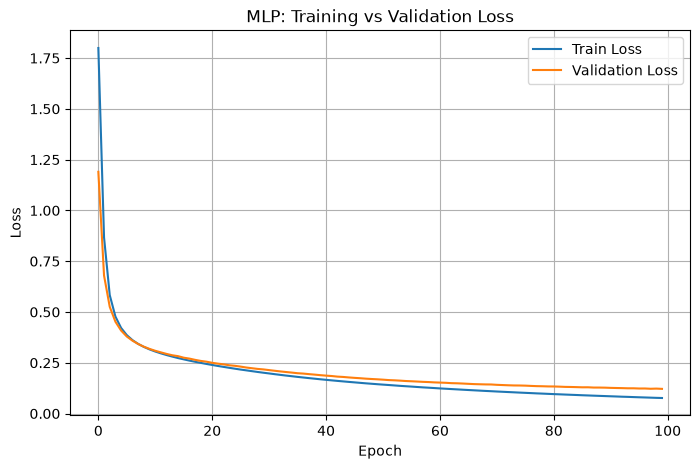

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses_mlp, label="Train Loss")
plt.plot(val_losses_mlp, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP: Training vs Validation Loss")

plt.legend()
plt.grid()
plt.show()

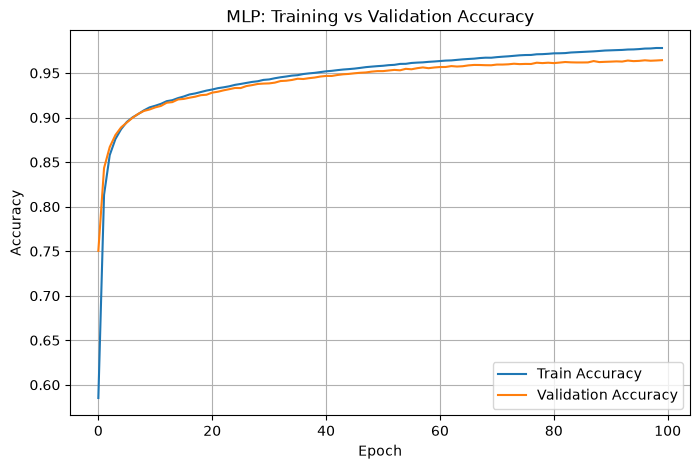

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies_mlp, label="Train Accuracy")
plt.plot(val_accuracies_mlp, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP: Training vs Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

In [20]:
from sklearn.metrics import accuracy_score, f1_score

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for X_batch, Y_batch in test_loader:

        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        outputs = model(X_batch)

        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(Y_batch.cpu().numpy())

In [21]:
test_accuracy_mlp = accuracy_score(
    all_labels,
    all_predictions
)

test_f1_mlp = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(f"MLP Test Accuracy: {test_accuracy_mlp:.4f}")
print(f"MLP Test F1 Score: {test_f1_mlp:.4f}")

MLP Test Accuracy: 0.9619
MLP Test F1 Score: 0.9618


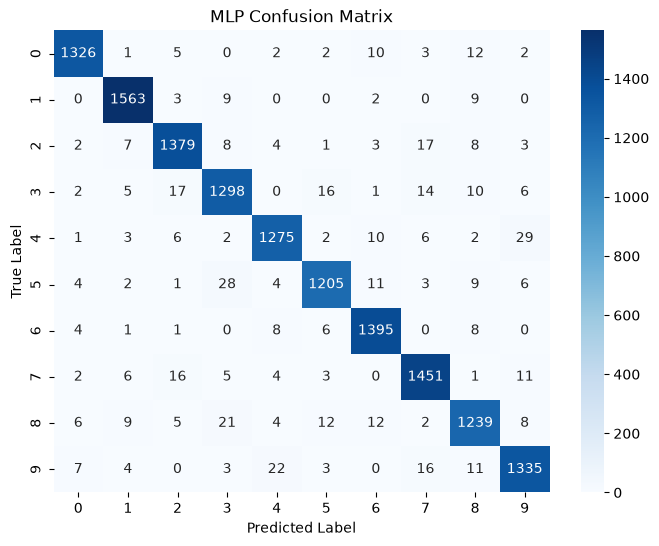

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MLP Confusion Matrix")

plt.show()

In [23]:
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),

    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),

    nn.Linear(128, 10)
)

In [24]:
# Convert NumPy arrays to PyTorch tensors

X_train_tensor = torch.tensor(x_train_norm, dtype=torch.float32)
X_val_tensor   = torch.tensor(x_val_norm, dtype=torch.float32)
X_test_tensor  = torch.tensor(x_test_norm, dtype=torch.float32)

Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)
Y_val_tensor   = torch.tensor(Y_val, dtype=torch.long)
Y_test_tensor  = torch.tensor(Y_test, dtype=torch.long)

In [25]:
# Add channel dimension for CNN

X_train_tensor = X_train_tensor.unsqueeze(1)
X_val_tensor   = X_val_tensor.unsqueeze(1)
X_test_tensor  = X_test_tensor.unsqueeze(1)

In [26]:
print(X_train_tensor.shape)
print(X_val_tensor.shape)
print(X_test_tensor.shape)

torch.Size([42000, 1, 28, 28])
torch.Size([14000, 1, 28, 28])
torch.Size([14000, 1, 28, 28])


In [27]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, Y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, Y_test_tensor)

In [28]:
# batch_size = 10

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [29]:
criterion = nn.CrossEntropyLoss()

In [30]:
# learning_rate = 0.0001

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

In [ ]:
# epochs = 100

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, Y_batch in train_loader:

        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        # Forward pass
        outputs = model(X_batch)

        # Calculate loss
        loss = criterion(outputs, Y_batch)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        running_loss += loss.item()

        # Predictions
        _, predicted = torch.max(outputs, 1)

        total += Y_batch.size(0)
        correct += (predicted == Y_batch).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, Y_batch in val_loader:

            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, Y_batch)

            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += Y_batch.size(0)
            correct += (predicted == Y_batch).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = correct / total

    # Store results
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/100] Train Loss: 1.1067 Train Acc: 0.7388 Val Loss: 0.4745 Val Acc: 0.8705
Epoch [2/100] Train Loss: 0.3823 Train Acc: 0.8904 Val Loss: 0.3315 Val Acc: 0.9037
Epoch [3/100] Train Loss: 0.3004 Train Acc: 0.9116 Val Loss: 0.2816 Val Acc: 0.9177
Epoch [4/100] Train Loss: 0.2573 Train Acc: 0.9240 Val Loss: 0.2431 Val Acc: 0.9300
Epoch [5/100] Train Loss: 0.2246 Train Acc: 0.9337 Val Loss: 0.2159 Val Acc: 0.9380
Epoch [6/100] Train Loss: 0.1974 Train Acc: 0.9417 Val Loss: 0.1899 Val Acc: 0.9460
Epoch [7/100] Train Loss: 0.1744 Train Acc: 0.9486 Val Loss: 0.1684 Val Acc: 0.9519
Epoch [8/100] Train Loss: 0.1546 Train Acc: 0.9539 Val Loss: 0.1521 Val Acc: 0.9574
Epoch [9/100] Train Loss: 0.1384 Train Acc: 0.9589 Val Loss: 0.1386 Val Acc: 0.9616
Epoch [10/100] Train Loss: 0.1243 Train Acc: 0.9634 Val Loss: 0.1266 Val Acc: 0.9646
Epoch [11/100] Train Loss: 0.1129 Train Acc: 0.9659 Val Loss: 0.1165 Val Acc: 0.9666
Epoch [12/100] Train Loss: 0.1030 Train Acc: 0.9693 Val Loss: 0.1058 Val A

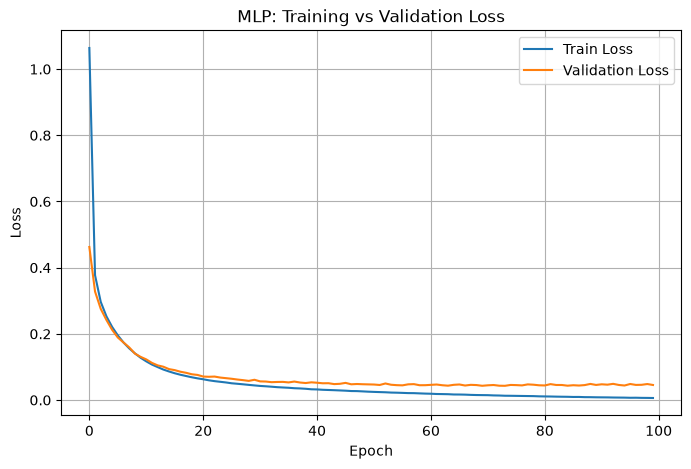

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP: Training vs Validation Loss")

plt.legend()
plt.grid()
plt.show()

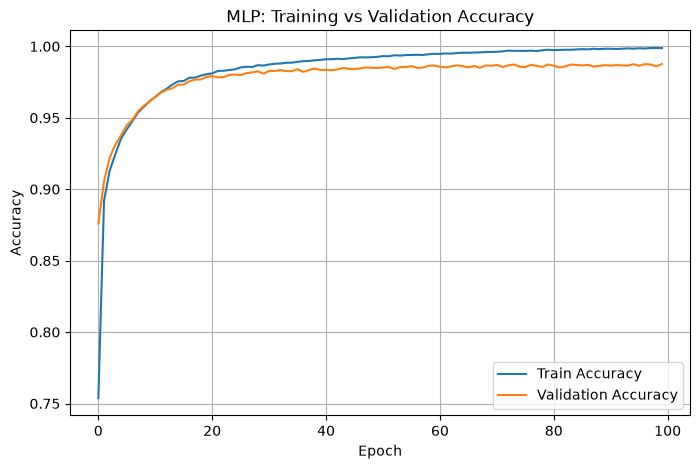

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP: Training vs Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for X_batch, Y_batch in test_loader:

        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        outputs = model(X_batch)

        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(Y_batch.cpu().numpy())

In [ ]:
test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(f"MLP Test Accuracy: {test_accuracy:.4f}")
print(f"MLP Test F1 Score: {test_f1:.4f}")

MLP Test Accuracy: 0.9858
MLP Test F1 Score: 0.9858


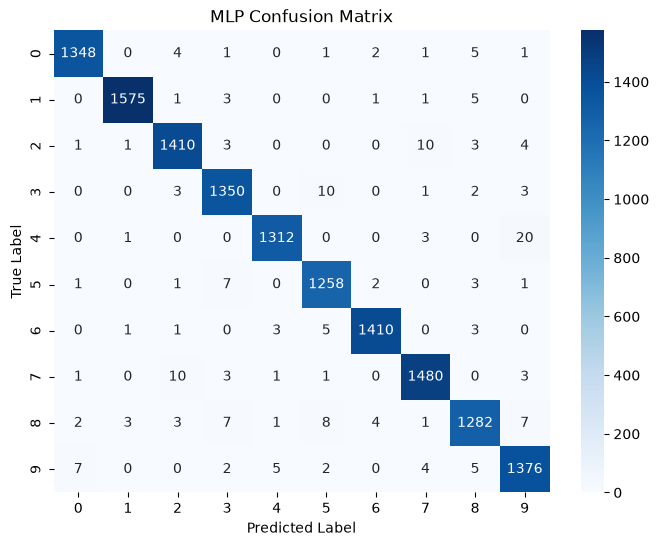

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MLP Confusion Matrix")

plt.show()

In [ ]:
# ============================================
# MLP vs CNN - Final Comparison
# ============================================

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --------------------------------------------
# Store CNN results using clear names
# --------------------------------------------

test_accuracy_cnn = test_accuracy
test_f1_cnn = test_f1

# --------------------------------------------
# Comparison table
# --------------------------------------------

print("=" * 50)
print("        MLP vs CNN TEST RESULTS")
print("=" * 50)

print(f"{'Metric':<20} {'MLP':>12} {'CNN':>12}")
print("-" * 50)

print(
    f"{'Test Accuracy':<20} "
    f"{test_accuracy_mlp:>11.4f} "
    f"{test_accuracy_cnn:>11.4f}"
)

print(
    f"{'Test F1 Score':<20} "
    f"{test_f1_mlp:>11.4f} "
    f"{test_f1_cnn:>11.4f}"
)

print("=" * 50)

# Percentage form

print("\nPercentage Results:")
print(f"MLP Test Accuracy : {test_accuracy_mlp * 100:.2f}%")
print(f"MLP Test F1 Score : {test_f1_mlp * 100:.2f}%")
print(f"CNN Test Accuracy : {test_accuracy_cnn * 100:.2f}%")
print(f"CNN Test F1 Score : {test_f1_cnn * 100:.2f}%")

        MLP vs CNN TEST RESULTS
Metric                        MLP          CNN
--------------------------------------------------
Test Accuracy             0.9641      0.9858
Test F1 Score             0.9641      0.9858

Percentage Results:
MLP Test Accuracy : 96.41%
MLP Test F1 Score : 96.41%
CNN Test Accuracy : 98.58%
CNN Test F1 Score : 98.58%


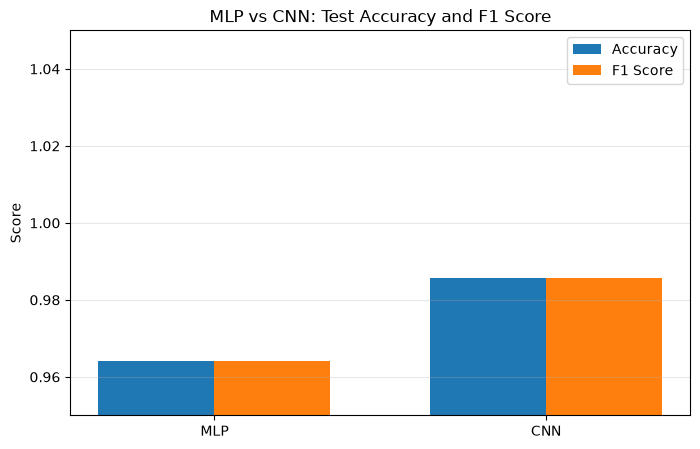

In [ ]:
# ============================================
# Accuracy and F1 Score Comparison
# ============================================

models = ["MLP", "CNN"]

accuracy_values = [
    test_accuracy_mlp,
    test_accuracy_cnn
]

f1_values = [
    test_f1_mlp,
    test_f1_cnn
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width/2,
    accuracy_values,
    width,
    label="Accuracy"
)

plt.bar(
    x + width/2,
    f1_values,
    width,
    label="F1 Score"
)

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("MLP vs CNN: Test Accuracy and F1 Score")
plt.ylim(0.95, 1.05)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

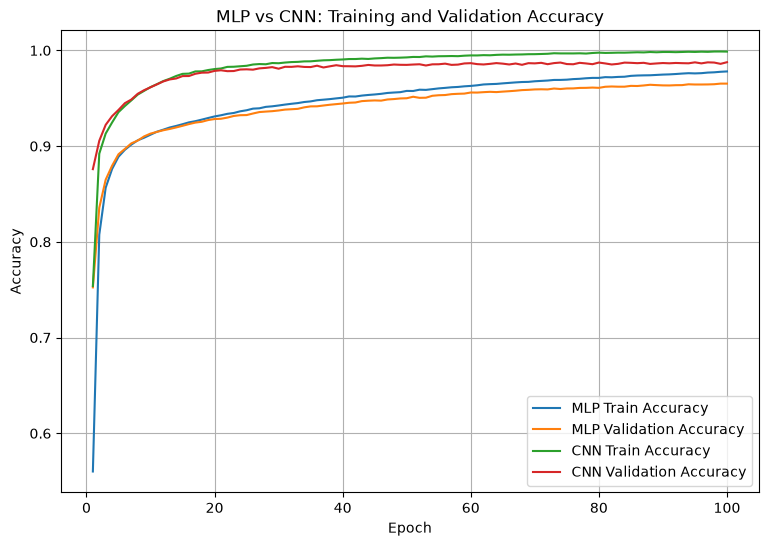

In [ ]:
# ============================================
# Training vs Validation Accuracy
# MLP vs CNN
# ============================================

plt.figure(figsize=(9, 6))

plt.plot(
    range(1, len(train_accuracies_mlp) + 1),
    train_accuracies_mlp,
    label="MLP Train Accuracy"
)

plt.plot(
    range(1, len(val_accuracies_mlp) + 1),
    val_accuracies_mlp,
    label="MLP Validation Accuracy"
)

plt.plot(
    range(1, len(train_accuracies) + 1),
    train_accuracies,
    label="CNN Train Accuracy"
)

plt.plot(
    range(1, len(val_accuracies) + 1),
    val_accuracies,
    label="CNN Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP vs CNN: Training and Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

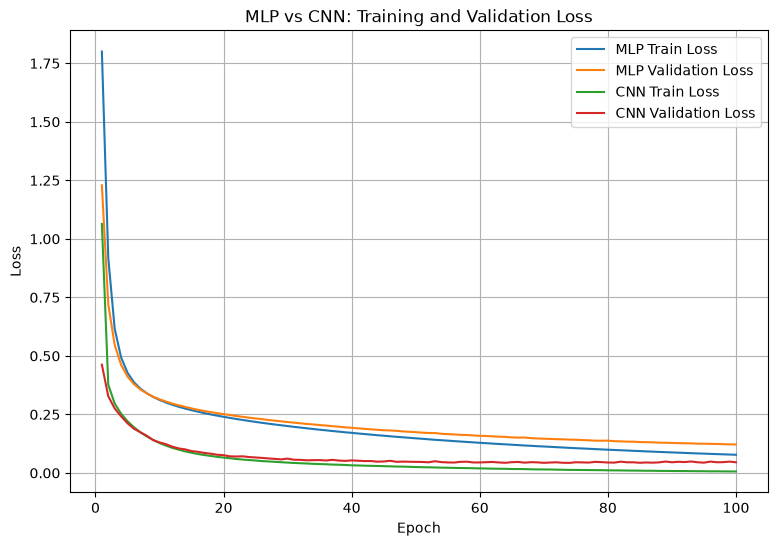

In [ ]:
# ============================================
# Training vs Validation Loss
# MLP vs CNN
# ============================================

plt.figure(figsize=(9, 6))

plt.plot(
    range(1, len(train_losses_mlp) + 1),
    train_losses_mlp,
    label="MLP Train Loss"
)

plt.plot(
    range(1, len(val_losses_mlp) + 1),
    val_losses_mlp,
    label="MLP Validation Loss"
)

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    label="CNN Train Loss"
)

plt.plot(
    range(1, len(val_losses) + 1),
    val_losses,
    label="CNN Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP vs CNN: Training and Validation Loss")

plt.legend()
plt.grid()

plt.show()